In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('/content/Inventory demand forecast.csv')
df.sample(5)

,date,store,item,sales
706387,2017-04-01,7,39,44
804377,2015-07-27,1,45,82
717362,2017-04-20,3,40,33
461112,2015-08-19,3,26,61
394220,2017-06-19,6,22,74


In [6]:
df['date']=pd.to_datetime(df['date'])
df['store']=df['store'].astype('int8')
df['item']=df['item'].astype('int8')
df['sales']=df['sales'].astype('int16')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int8          
 2   item    913000 non-null  int8          
 3   sales   913000 non-null  int16         
dtypes: datetime64[ns](1), int16(1), int8(2)
memory usage: 10.4 MB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


In [10]:
print(df['date'].min())
print(df['date'].max())

2013-01-01 00:00:00
2017-12-31 00:00:00


In [11]:
df['store'].nunique()

10

In [12]:
df['item'].nunique()

50

In [13]:
df.groupby(['store','item']).ngroups

500

EDA

[]

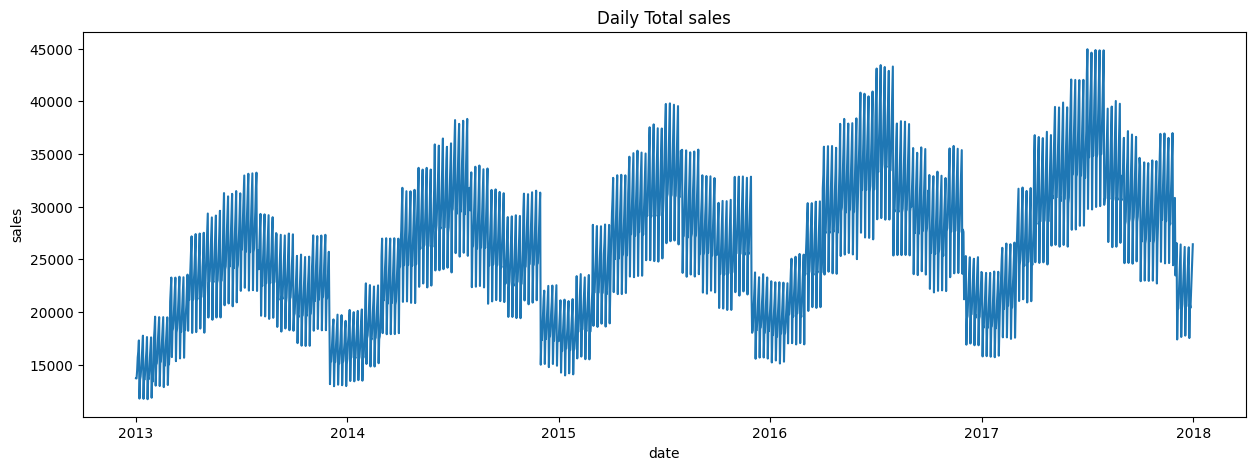

In [14]:
daily_sales=df.groupby('date')['sales'].sum()
plt.figure(figsize=(15,5))
plt.plot(daily_sales)
plt.title('Daily Total sales')
plt.xlabel('date')
plt.ylabel('sales')
plt.plot()

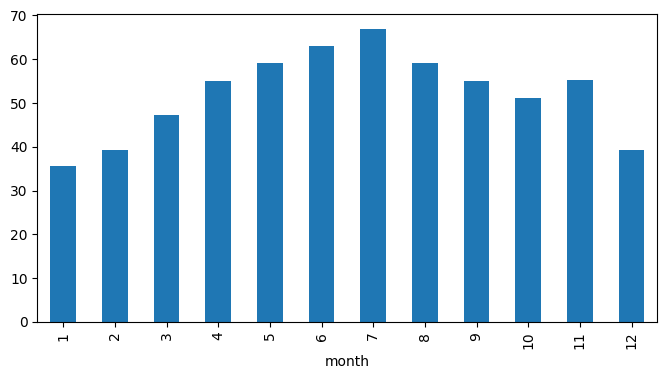

In [15]:
df['month']=df['date'].dt.month
monthly_sales=df.groupby('month')['sales'].mean()
monthly_sales.plot(kind='bar',figsize=(8,4))
plt.show()

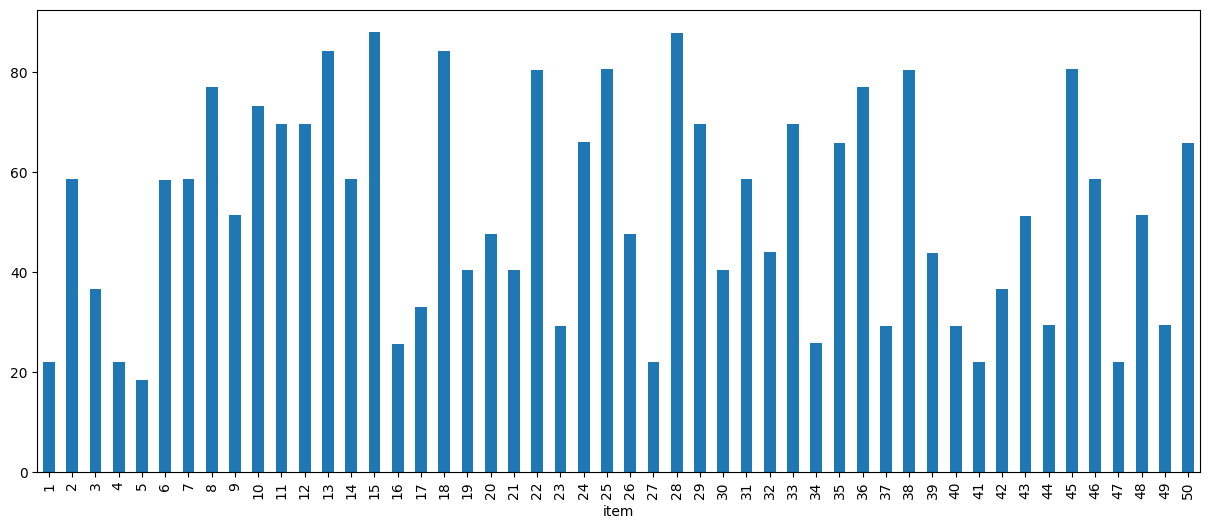

In [16]:
item_sales=df.groupby('item')['sales'].mean()
item_sales.plot(kind='bar',figsize=(15,6))
plt.show()

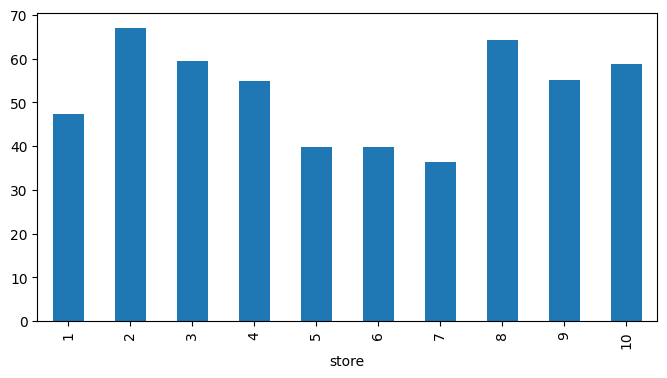

In [17]:
store_sales=df.groupby('store')['sales'].mean()
store_sales.plot(kind='bar',figsize=(8,4))
plt.show()

Feature Engineering

In [18]:
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month
df['day']=df['date'].dt.day
df['day_of_week']=df['date'].dt.dayofweek
df['week_of_year']=df['date'].dt.isocalendar().week
df['quarter']=df['date'].dt.quarter
df['weekend']=(df['day_of_week']>=5).astype(int)

In [19]:
df=df.sort_values(by=['store','item','date'])
df=df.reset_index(drop=True)

In [20]:
lags=[1,7,30,90]
for lag in lags:
  df[f'lag_{lag}']=df.groupby(['store','item'])['sales'].shift(lag)

In [21]:
windows=[7,30]
for window in windows:
  df[f'rolling_mean_{window}']=df.groupby(['store','item'])['sales'].transform(lambda x: x.shift(1).rolling(window).mean())
  df[f'rolling_std_{window}']=df.groupby(['store','item'])['sales'].transform(lambda x: x.shift(1).rolling(window).std())

In [22]:
df['expanding_mean']=df.groupby(['store','item'])['sales'].transform(lambda x:x.shift(1).expanding().mean())

expanding(): Unlike rolling(), which uses a fixed-size window, expanding() calculates a statistic (in this case, the mean) for all data points up to the current point. As you move through the series, the window expands to include all previous data.

In [23]:
df['month_sin']=np.sin(2*np.pi*df['month']/12)
df['month_cos']=np.cos(2*np.pi*df['month']/12)
df['dow_sin']=np.sin(2*np.pi*df['day_of_week']/7)
df['dow_cos']=np.cos(2*np.pi*df['day_of_week']/7)

Cyclical encoding is a technique used in machine learning to represent cyclical features, like months of the year or days of the week, in a way that respects their inherent circular nature. For example, December (month 12) is closer to January (month 1) than it is to June (month 6), but a linear numerical representation (1, 2, ..., 12) doesn't capture this relationship.

You are transforming the 'month' and 'day_of_week' features into two new features each using sine and cosine functions. Here's why and how:

df['month_sin']=np.sin(2*np.pi*df['month']/12) and df['month_cos']=np.cos(2*np.pi*df['month']/12):

df['month'] ranges from 1 to 12. To map this to a circle, you're essentially converting the month number into an angle.
2 * np.pi represents a full circle in radians (360 degrees).
Dividing by 12 (the maximum value for month) scales each month's value to a fraction of a full circle.
np.sin() and np.cos() then project this angle onto two dimensions (sine and cosine components).
This ensures that December (12) and January (1) will have very similar sine and cosine values, capturing their proximity.
df['dow_sin']=np.sin(2*np.pi*df['day_of_week']/7) and df['dow_cos']=np.cos(2*np.pi*df['day_of_week']/7):

This does the same for the 'day_of_week' feature, which typically ranges from 0 (Monday) to 6 (Sunday).
It divides by 7 (the number of days in a week) to scale the days into a circle.
This way, Sunday (6) and Monday (0) will have similar encoded values, reflecting that they are adjacent in the week.
Why use it? Models like linear regression or tree-based models might struggle to understand that the 'distance' between month 12 and month 1 is small. By using sine and cosine transformations, these models can interpret cyclical features more effectively, as the values for the beginning and end of a cycle become numerically close.

In [24]:
df.isnull().sum().sort_values(ascending=False)

,0
lag_90,45000
rolling_mean_30,15000
lag_30,15000
rolling_std_30,15000
rolling_std_7,3500
lag_7,3500
rolling_mean_7,3500
lag_1,500
expanding_mean,500
day,0


In [25]:
df.dropna(inplace=True)
df.reset_index(drop=True,inplace=True)

In [27]:
df.shape

(868000, 24)

In [28]:
df.info(

)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 868000 entries, 0 to 867999
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             868000 non-null  datetime64[ns]
 1   store            868000 non-null  int8          
 2   item             868000 non-null  int8          
 3   sales            868000 non-null  int16         
 4   month            868000 non-null  int32         
 5   year             868000 non-null  int32         
 6   day              868000 non-null  int32         
 7   day_of_week      868000 non-null  int32         
 8   week_of_year     868000 non-null  UInt32        
 9   quarter          868000 non-null  int32         
 10  weekend          868000 non-null  int64         
 11  lag_1            868000 non-null  float64       
 12  lag_7            868000 non-null  float64       
 13  lag_30           868000 non-null  float64       
 14  lag_90           868

In [29]:
df.head()

,date,store,item,sales,month,year,day,day_of_week,week_of_year,quarter,...,lag_90,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30,expanding_mean,month_sin,month_cos,dow_sin,dow_cos
0,2013-04-01,1,1,11,4,2013,1,0,14,2,...,13.0,15.571429,3.359422,15.400000,3.596934,12.522222,0.866025,-0.5,0.000000,1.000000
1,2013-04-02,1,1,19,4,2013,2,1,14,2,...,11.0,15.285714,3.683942,15.333333,3.660915,12.505495,0.866025,-0.5,0.781831,0.623490
2,2013-04-03,1,1,24,4,2013,3,2,14,2,...,14.0,15.714286,3.946065,15.300000,3.621297,12.576087,0.866025,-0.5,0.974928,-0.222521
3,2013-04-04,1,1,18,4,2013,4,3,14,2,...,13.0,17.571429,4.391550,15.633333,3.943422,12.698925,0.866025,-0.5,0.433884,-0.900969
4,2013-04-05,1,1,19,4,2013,5,4,14,2,...,10.0,18.285714,3.903600,15.800000,3.933937,12.755319,0.866025,-0.5,-0.433884,-0.900969


In [30]:
df['month']=df['month'].astype('int8')
df['year']=df['year'].astype('int8')
df['day']=df['day'].astype('int8')
df['day_of_week']=df['day_of_week'].astype('int8')
df['week_of_year']=df['week_of_year'].astype('int8')
df['quarter']=df['quarter'].astype('int8')
df['weekend']=df['weekend'].astype('int8')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 868000 entries, 0 to 867999
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             868000 non-null  datetime64[ns]
 1   store            868000 non-null  int8          
 2   item             868000 non-null  int8          
 3   sales            868000 non-null  int16         
 4   month            868000 non-null  int8          
 5   year             868000 non-null  int8          
 6   day              868000 non-null  int8          
 7   day_of_week      868000 non-null  int8          
 8   week_of_year     868000 non-null  int8          
 9   quarter          868000 non-null  int8          
 10  weekend          868000 non-null  int8          
 11  lag_1            868000 non-null  float64       
 12  lag_7            868000 non-null  float64       
 13  lag_30           868000 non-null  float64       
 14  lag_90           868

In [34]:
features = [
    'store',
    'item',
    'month',
    'year',
    'day',
    'day_of_week',
    'week_of_year',
    'quarter',
    'weekend',
    'lag_1',
    'lag_7',
    'lag_30',
    'lag_90',
    'rolling_mean_7',
    'rolling_std_7',
    'rolling_mean_30',
    'rolling_std_30',
    'expanding_mean',
    'month_sin',
    'month_cos',
    'dow_sin',
    'dow_cos'
]

In [35]:
target='sales'

In [36]:
train=df[df['date']<'2017-01-01']
test=df[df['date']>='2017-01-01']

In [37]:
X_train=train[features]
X_test=test[features]
y_train=train[target]
y_test=test[target]

In [38]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)

LinearRegression()

In [39]:
lr_pred=lr_model.predict(X_test)

In [41]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mae=mean_absolute_error(y_test,lr_pred)
mse=mean_squared_error(y_test,lr_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,lr_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("MSE:", mse)
print("R2:", r2)

MAE: 6.9814294834303405
RMSE: 9.107526394221981
MSE: 82.94703702145003
R2: 0.9166836431911071


In [42]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1.0)
ridge.fit(X_train,y_train)

Ridge()

In [43]:
ridge_pred=ridge.predict(X_test)

In [44]:
mae=mean_absolute_error(y_test,ridge_pred)
mse=mean_squared_error(y_test,ridge_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,ridge_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("MSE:", mse)
print("R2:", r2)

MAE: 6.981429072151481
RMSE: 9.107526591698184
MSE: 82.94704061848952
R2: 0.9166836395780518


In [45]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.01)
lasso.fit(X_train,y_train)

Lasso(alpha=0.01)

In [52]:
lasso_pred=lasso.predict(X_test)

In [53]:
mae=mean_absolute_error(y_test,lasso_pred)
mse=mean_squared_error(y_test,lasso_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,lasso_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("MSE:", mse)
print("R2:", r2)

MAE: 6.979704267458804
RMSE: 9.107683412300105
MSE: 82.94989713868648
R2: 0.916680770339264


In [54]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(
    n_estimators=50,
    n_jobs=-1,
    max_depth=15,
    random_state=42
)

In [55]:
rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=15, n_estimators=50, n_jobs=-1, random_state=42)

In [56]:
rf_pred=rf.predict(X_test)
mae=mean_absolute_error(y_test,rf_pred)
mse=mean_squared_error(y_test,rf_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,rf_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("MSE:", mse)
print("R2:", r2)

MAE: 6.213132090579132
RMSE: 8.101216362957814
MSE: 65.62970655945544
R2: 0.9340780786713755


In [57]:
import joblib

joblib.dump(lr_model, 'linear_regression_inventory_demand_forecaster.joblib')
print("Linear Regression model saved as 'linear_regression_model.joblib'")

joblib.dump(ridge, 'ridge_inventory_demand_forecaster.joblib')
print("Ridge model saved as 'ridge_model.joblib'")

joblib.dump(lasso, 'lasso_inventory_demand_forecaster.joblib')
print("Lasso model saved as 'lasso_model.joblib'")

joblib.dump(rf, 'random_forest_inventory_demand_forecaster.joblib')
print("Random Forest model saved as 'random_forest_model.joblib'")

Linear Regression model saved as 'linear_regression_model.joblib'
Ridge model saved as 'ridge_model.joblib'
Lasso model saved as 'lasso_model.joblib'
Random Forest model saved as 'random_forest_model.joblib'


In [58]:
joblib.dump(rf, 'random_forest_inventory_demand_forecaster.joblib')
print("Random Forest model saved as 'random_forest_model.joblib'")

Random Forest model saved as 'random_forest_model.joblib'
